In [1]:
# ── Imports ──
# Grisham V1 — same architecture as Witt V10, Schwarber V2
# 8 features: era, park_factor, pitcher_r, is_home,
#             avg_exit_velo_15, barrel_rate_15, hard_hit_rate_15, hr_zone_rate_15
# Key differences:
#   - Grisham bats LEFT — pitcher_r expected > 1 (platoon advantage vs RHP)
#   - Yankee Stadium (team_id 147) — short porch favors lefty pull hitters
#   - Leadoff hitter — different pitch environment than protection hitters
#   - 34 HR in 2025 but career historically lower — watch base rate
import sys
sys.path.append("../scripts")

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sqlalchemy import text
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score
from pybaseball import statcast_batter
from data_collection import engine


In [2]:
# ── Load base dataset from database ──
# Grisham player_id = 663757
PLAYER_ID = 663757

with engine.connect() as conn:
    df = pd.read_sql(text("""
        SELECT
            w.game_id,
            w.date,
            w.season,
            w.home_away,
            w.tb,
            w.hr,
            w.opponent_id,
            p.throws,
            p.era,
            p.k_per_9,
            pf.park_factor,
            pf.park_factor_hr
        FROM player_game_logs w
        JOIN pitcher_game_logs p ON w.game_id = p.game_id
        JOIN park_factors pf ON (
            CASE WHEN w.home_away = 'home' THEN 147
                 ELSE w.opponent_id
            END = pf.team_id
        )
        WHERE w.player_id = :pid
        ORDER BY w.date
    """), conn, params={"pid": PLAYER_ID})

print(f"Base dataset: {df.shape}")
print(df[['date', 'hr', 'tb', 'era']].head(10))


Base dataset: (534, 12)
         date  hr  tb    era
0  2022-04-07   0   1   4.20
1  2022-04-08   0   1   4.20
2  2022-04-09   0   0   4.20
3  2022-04-10   0   1   4.20
4  2022-04-11   0   1   4.20
5  2022-04-12   0   0   0.00
6  2022-04-13   0   0   0.00
7  2022-04-14   0   0   3.38
8  2022-04-15   0   2   0.00
9  2022-04-16   1   4  16.87


In [3]:
# ── HR distribution and base rate ──
print("HR distribution:")
print(df['hr'].value_counts().sort_index())

hr_rate = (df['hr'] >= 1).mean()
print(f"\nGames with 0 HR:  {(df['hr'] == 0).mean():.3f}")
print(f"Games with 1+ HR: {hr_rate:.3f} ({hr_rate*100:.1f}% of games)")
print(f"Games with 2+ HR: {(df['hr'] >= 2).mean():.3f}")

breakeven = -hr_rate / (1 - hr_rate) * 100
print(f"\nBreak-even American odds: {breakeven:.0f}")
print(f"\n(Witt: 16.0%, Schwarber: 25.7% for comparison)")


HR distribution:
hr
0    466
1     63
2      5
Name: count, dtype: int64

Games with 0 HR:  0.873
Games with 1+ HR: 0.127 (12.7% of games)
Games with 2+ HR: 0.009

Break-even American odds: -15

(Witt: 16.0%, Schwarber: 25.7% for comparison)


In [4]:
# ── Pull Statcast data via pybaseball ──
# Grisham player_id = 663757
print("Pulling Statcast data...")
statcast_raw = statcast_batter('2022-04-01', '2025-10-01', player_id=663757)
print(f"Statcast raw: {statcast_raw.shape}")


Pulling Statcast data...
Gathering Player Data
Statcast raw: (8592, 118)


In [5]:
# ── Aggregate Statcast to game level ──
batted = statcast_raw[statcast_raw['launch_speed'].notna()].copy()

# HR zone: 25-35 degree launch angle band — where balls most frequently leave the park
batted['in_hr_zone'] = batted['launch_angle'].between(25, 35).astype(int)

game_stats = batted.groupby('game_date').agg(
    avg_exit_velo=('launch_speed', 'mean'),
    barrel_count=('launch_speed_angle', lambda x: (x == 6).sum()),
    hard_hit_count=('launch_speed', lambda x: (x >= 95).sum()),
    hr_zone_count=('in_hr_zone', 'sum'),
    batted_balls=('launch_speed', 'count'),
).reset_index()

game_stats['barrel_rate']   = game_stats['barrel_count']   / game_stats['batted_balls']
game_stats['hard_hit_rate'] = game_stats['hard_hit_count'] / game_stats['batted_balls']
game_stats['hr_zone_rate']  = game_stats['hr_zone_count']  / game_stats['batted_balls']

print(f"Game-level Statcast: {game_stats.shape}")
print(game_stats[['game_date', 'barrel_rate', 'hr_zone_rate']].head(10))

Game-level Statcast: (525, 9)
    game_date  barrel_rate  hr_zone_rate
0  2022-04-07     0.142857      0.285714
1  2022-04-08     0.000000      0.166667
2  2022-04-09     0.000000      0.000000
3  2022-04-10     0.000000      0.000000
4  2022-04-11     0.000000      0.285714
5  2022-04-12     0.000000      0.000000
6  2022-04-13     0.200000      0.200000
7  2022-04-14     0.000000      0.000000
8  2022-04-15     0.000000      0.000000
9  2022-04-16     0.000000      0.200000


In [6]:
# ── Rolling Statcast features — 15-day window ──
game_stats = game_stats.sort_values('game_date').reset_index(drop=True)

game_stats['avg_exit_velo_15'] = game_stats['avg_exit_velo'].shift(1).rolling(15, min_periods=7).mean()
game_stats['barrel_rate_15']   = game_stats['barrel_rate'].shift(1).rolling(15, min_periods=7).mean()
game_stats['hard_hit_rate_15'] = game_stats['hard_hit_rate'].shift(1).rolling(15, min_periods=7).mean()
game_stats['hr_zone_rate_15']  = game_stats['hr_zone_rate'].shift(1).rolling(15, min_periods=7).mean()

print(game_stats[['game_date', 'barrel_rate_15', 'hr_zone_rate_15']].head(20))

     game_date  barrel_rate_15  hr_zone_rate_15
0   2022-04-07             NaN              NaN
1   2022-04-08             NaN              NaN
2   2022-04-09             NaN              NaN
3   2022-04-10             NaN              NaN
4   2022-04-11             NaN              NaN
5   2022-04-12             NaN              NaN
6   2022-04-13             NaN              NaN
7   2022-04-14        0.048980         0.134014
8   2022-04-15        0.042857         0.117262
9   2022-04-16        0.038095         0.104233
10  2022-04-20        0.034286         0.113810
11  2022-04-22        0.031169         0.103463
12  2022-04-23        0.028571         0.094841
13  2022-04-24        0.026374         0.087546
14  2022-04-26        0.024490         0.081293
15  2022-04-27        0.022857         0.086984
16  2022-04-28        0.013333         0.081270
17  2022-04-29        0.013333         0.086825
18  2022-04-30        0.013333         0.100159
19  2022-05-01        0.013333         0

In [7]:
# ── Merge Statcast into base dataset ──
game_stats['game_date'] = pd.to_datetime(game_stats['game_date'])
df['date'] = pd.to_datetime(df['date'])

df = df.merge(
    game_stats[['game_date', 'avg_exit_velo_15', 'barrel_rate_15',
                'hard_hit_rate_15', 'hr_zone_rate_15']],
    left_on='date',
    right_on='game_date',
    how='left'
)

print(f"After merge: {df.shape}")
print(df[['avg_exit_velo_15', 'barrel_rate_15', 'hr_zone_rate_15']].isnull().sum())

After merge: (534, 17)
avg_exit_velo_15    55
barrel_rate_15      55
hr_zone_rate_15     55
dtype: int64


In [8]:
# ── Feature engineering ──
df = df.sort_values('date').reset_index(drop=True)

df['is_home']   = (df['home_away'] == 'home').astype(int)
df['pitcher_r'] = (df['throws'] == 'R').astype(int)

# Grisham bats left — pitcher_r expected > 1 (platoon advantage vs RHP)
# Yankee Stadium short porch particularly favorable for lefty pull hitters

# Drop rows missing Statcast rolling features only
df_model = df.dropna(subset=['avg_exit_velo_15', 'barrel_rate_15',
                              'hr_zone_rate_15']).reset_index(drop=True)

print(f"Model dataset: {df_model.shape}")


Model dataset: (479, 19)


In [9]:
# ── Define features and binary target ──
# Grisham V1 feature set: 8 features (matching Schwarber V2 — no k_per_9)
# Will add k_per_9 back in V2 if signs are clean without it
FEATURES = [
    # Grisham contact quality
    'avg_exit_velo_15',
    'barrel_rate_15',
    'hard_hit_rate_15',
    'hr_zone_rate_15',
    # Game context
    'is_home',
    'pitcher_r',
    # Pitcher
    'era',
    # Park
    'park_factor',
]

X = df_model[FEATURES]
y_binary = (df_model['hr'] >= 1).astype(int)

print(f"Features: {len(FEATURES)}")
print(f"Dataset: {X.shape}")
print(f"HR rate: {y_binary.mean():.3f} ({y_binary.sum()} HR games out of {len(y_binary)})")
print(f"\n(Witt: 0.160, Schwarber: 0.257 for comparison)")


Features: 8
Dataset: (479, 8)
HR rate: 0.142 (68 HR games out of 479)

(Witt: 0.160, Schwarber: 0.257 for comparison)


In [10]:
# ── Scale features ──
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=FEATURES)

In [11]:
# ── Baseline ──
baseline_acc = 1 - y_binary.mean()
print(f"Baseline accuracy (always predict no HR): {baseline_acc:.3f}")
breakeven = -y_binary.mean() / (1 - y_binary.mean()) * 100
print(f"Break-even odds for HR prop: {breakeven:.0f}")

Baseline accuracy (always predict no HR): 0.858
Break-even odds for HR prop: -17


In [12]:
# ── Regularization tuning — grid search over C ──
# C controls regularization strength
# Low C = stronger regularization = simpler model, less overfit
# High C = weaker regularization = fits training data more closely
C_grid = [0.001, 0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0]

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    LogisticRegression(max_iter=500),
    param_grid={'C': C_grid},
    cv=tscv,
    scoring='roc_auc',
    refit=True,
    n_jobs=-1
)

grid_search.fit(X_scaled, y_binary)

best_C   = grid_search.best_params_['C']
best_auc = grid_search.best_score_

print(f"Best C:        {best_C}")
print(f"Best CV AUC:   {best_auc:.3f}")
print()

results = pd.DataFrame(grid_search.cv_results_)
print(results[['param_C', 'mean_test_score', 'std_test_score']].round(4).to_string(index=False))

Best C:        10.0
Best CV AUC:   0.517

 param_C  mean_test_score  std_test_score
   0.001           0.4864          0.0496
   0.010           0.4875          0.0523
   0.050           0.4891          0.0575
   0.100           0.4927          0.0585
   0.250           0.4988          0.0659
   0.500           0.5101          0.0728
   1.000           0.5128          0.0705
   2.000           0.5137          0.0723
   5.000           0.5160          0.0722
  10.000           0.5175          0.0728


In [13]:
# ── Cross-validation with best C ──
model = grid_search.best_estimator_

cv_auc = cross_val_score(model, X_scaled, y_binary, cv=tscv, scoring='roc_auc')
cv_acc = cross_val_score(model, X_scaled, y_binary, cv=tscv, scoring='accuracy')

print(f"CV AUC per fold:  {[round(v,3) for v in cv_auc]}")
print(f"CV ACC per fold:  {[round(v,3) for v in cv_acc]}")
print(f"\nAUC mean +/- std: {cv_auc.mean():.3f} +/- {cv_auc.std():.3f}")
print(f"ACC mean +/- std: {cv_acc.mean():.3f} +/- {cv_acc.std():.3f}")
print(f"\nBaseline ACC:     {baseline_acc:.3f}")
print(f"Improvement:      {cv_acc.mean() - baseline_acc:.3f}")
print(f"\nGrisham V1 CV AUC:   {cv_auc.mean():.3f}")
print(f"Witt V10 CV AUC:     0.567")
print(f"Schwarber V2 CV AUC: 0.527")
print(f"\n(AUC > 0.55 = meaningful signal for sports betting)")


CV AUC per fold:  [np.float64(0.584), np.float64(0.579), np.float64(0.504), np.float64(0.535), np.float64(0.384)]
CV ACC per fold:  [np.float64(0.848), np.float64(0.899), np.float64(0.911), np.float64(0.797), np.float64(0.772)]

AUC mean +/- std: 0.517 +/- 0.073
ACC mean +/- std: 0.846 +/- 0.055

Baseline ACC:     0.858
Improvement:      -0.012

Grisham V1 CV AUC:   0.517
Witt V10 CV AUC:     0.567
Schwarber V2 CV AUC: 0.527

(AUC > 0.55 = meaningful signal for sports betting)


In [14]:
# ── Fit on full dataset ──
model.fit(X_scaled, y_binary)
df_model['p_hr'] = model.predict_proba(X_scaled)[:, 1]

insample_auc = roc_auc_score(y_binary, df_model['p_hr'])
insample_acc = accuracy_score(y_binary, model.predict(X_scaled))

print(f"In-sample AUC:  {insample_auc:.3f}")
print(f"In-sample ACC:  {insample_acc:.3f}")
print(f"CV AUC:         {cv_auc.mean():.3f}")
print(f"\nGap (in-sample - CV AUC): {insample_auc - cv_auc.mean():.3f}")
print("(smaller gap = less overfitting)")
print(f"\nMean P(HR):     {df_model['p_hr'].mean():.3f}")
print(f"Actual HR rate: {y_binary.mean():.3f}")

In-sample AUC:  0.622
In-sample ACC:  0.858
CV AUC:         0.517

Gap (in-sample - CV AUC): 0.104
(smaller gap = less overfitting)

Mean P(HR):     0.142
Actual HR rate: 0.142


In [15]:
# ── Calibration table ──
df_model['pred_bin'] = pd.qcut(df_model['p_hr'], q=5, labels=False)

calibration = df_model.groupby('pred_bin').agg(
    mean_predicted=('p_hr', 'mean'),
    actual_rate=('hr', lambda x: (x >= 1).mean()),
    n=('hr', 'count')
).round(3)

print(calibration)
spread = calibration['actual_rate'].iloc[-1] - calibration['actual_rate'].iloc[0]
print(f"\nSpread (bin 4 - bin 0): {spread:.3f}")
print(f"V6 spread:              0.185")
print(f"V5 spread:              ~0.12")
print("\n(larger spread = better discrimination between HR and non-HR games)")

          mean_predicted  actual_rate   n
pred_bin                                 
0                  0.083        0.062  96
1                  0.107        0.104  96
2                  0.130        0.137  95
3                  0.164        0.208  96
4                  0.226        0.198  96

Spread (bin 4 - bin 0): 0.136
V6 spread:              0.185
V5 spread:              ~0.12

(larger spread = better discrimination between HR and non-HR games)


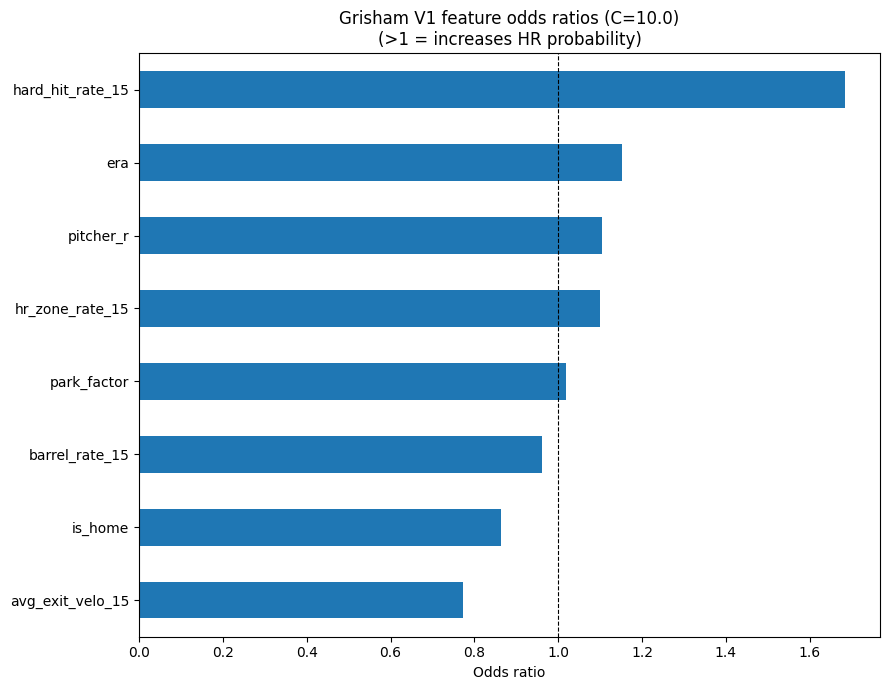


Odds ratios:
avg_exit_velo_15    0.773
is_home             0.863
barrel_rate_15      0.962
park_factor         1.020
hr_zone_rate_15     1.101
pitcher_r           1.104
era                 1.152
hard_hit_rate_15    1.684
dtype: float64


In [16]:
# ── Feature odds ratios ──
# Expected directions:
#   era        > 1 — higher ERA = worse pitcher = more HRs
#   park_factor > 1 — Yankee Stadium short porch favors lefty pull hitters
#   pitcher_r  > 1 — Grisham bats left, platoon advantage vs RHP
#   is_home    > 1 — home field advantage at Yankee Stadium
#   Statcast   uncertain — watch whether hot streaks persist like Schwarber or revert like Witt
coefs = pd.Series(model.coef_[0], index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
np.exp(coefs).sort_values().plot(kind='barh', ax=ax)
ax.axvline(1.0, color='black', linestyle='--', linewidth=0.8)
ax.set_title(f'Grisham V1 feature odds ratios (C={best_C})\n(>1 = increases HR probability)')
ax.set_xlabel('Odds ratio')
plt.tight_layout()
plt.show()

print("\nOdds ratios:")
print(np.exp(coefs).round(3))


In [17]:
# ── Implied odds converter ──
def prob_to_american_odds(p):
    if p >= 0.5:
        return round(-p / (1 - p) * 100)
    else:
        return round((1 - p) / p * 100)

sample = df_model[['date', 'hr', 'p_hr']].copy()
sample['implied_odds'] = sample['p_hr'].apply(prob_to_american_odds)
sample['result'] = (sample['hr'] >= 1).map({True: '✅ HR', False: '❌ No HR'})

print("Last 20 games — model probability vs actual result:")
print(sample[['date', 'p_hr', 'implied_odds', 'result']].tail(20).to_string())

Last 20 games — model probability vs actual result:
          date      p_hr  implied_odds   result
459 2025-09-04  0.179170           458     ✅ HR
460 2025-09-05  0.170437           487  ❌ No HR
461 2025-09-06  0.196546           409  ❌ No HR
462 2025-09-07  0.168306           494  ❌ No HR
463 2025-09-09  0.156617           539  ❌ No HR
464 2025-09-10  0.202877           393  ❌ No HR
465 2025-09-12  0.228675           337  ❌ No HR
466 2025-09-13  0.172671           479  ❌ No HR
467 2025-09-15  0.180599           454  ❌ No HR
468 2025-09-16  0.200319           399     ✅ HR
469 2025-09-17  0.204461           389     ✅ HR
470 2025-09-18  0.204176           390  ❌ No HR
471 2025-09-20  0.224168           346  ❌ No HR
472 2025-09-21  0.185933           438  ❌ No HR
473 2025-09-23  0.145801           586  ❌ No HR
474 2025-09-24  0.097084           930     ✅ HR
475 2025-09-25  0.142377           602  ❌ No HR
476 2025-09-26  0.099776           902  ❌ No HR
477 2025-09-27  0.190076           4

In [18]:
# ── Save model artifacts ──
joblib.dump(model,  '../models/grisham_hr_logistic_v1_model.pkl')
joblib.dump(scaler, '../models/grisham_hr_logistic_v1_scaler.pkl')
print("Saved:")
print("  models/grisham_hr_logistic_v1_model.pkl")
print("  models/grisham_hr_logistic_v1_scaler.pkl")
print(f"\nBest C: {best_C}")
print(f"Features ({len(FEATURES)}): {FEATURES}")


Saved:
  models/grisham_hr_logistic_v1_model.pkl
  models/grisham_hr_logistic_v1_scaler.pkl

Best C: 10.0
Features (8): ['avg_exit_velo_15', 'barrel_rate_15', 'hard_hit_rate_15', 'hr_zone_rate_15', 'is_home', 'pitcher_r', 'era', 'park_factor']
